In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib notebook
import random as rand
from runtumble import Cell, Wall, Particle

In [3]:
# Initialisation
c = Cell(xsize=30, ysize=10, default_walls=False)
p = Particle()
c.add_particle(p)
walls = [Wall(0,0,0,10), Wall(30,0,30,10), Wall(10,0,10,5), Wall(10,5,5,5), 
        Wall(20,0,20,5), Wall(20,5,15,5), Wall(30,5,25,5)]
for w in walls:
    c.add_wall(w)

In [4]:
c.set_field(0)
c.set_pbc(False)
c.set_velocity(0.5)
c.set_decay_rate(0.5)
c.set_particle_radius(0.1)
print(f"field: {p.FIELD}\nperiodic bc: {p.PERIODIC_BC}\nvelocity: {p.VELOCITY}\ndecay rate: {p.RATE}\nradius: {p.RADIUS}")

field: 0
periodic bc: False
velocity: 0.5
decay rate: 0.5
radius: 0.1


In [5]:
def simulation(n_sim, n_step):
    path = []
    R = p.RADIUS
    for j in range(n_sim):
        x0, y0 = R + rand.random() * (c.cell_size[0] - 2 * R), R + rand.random() * (c.cell_size[1] - 2 * R)

        p.set_r(x0, y0)
        p.tumble()

        for i in range(n_step):
            path.append(p.get_r())
            p.run(0.1)
            print(f"{j+1:0>3d}: {i+1:0>5d}", end='\r')
    return np.array(path)

In [10]:
path = simulation(300, 10000)

In [11]:
# np.savetxt('sims/3_cell_density_300_10000_0.1.txt', path)

In [6]:
path = np.loadtxt('sims/3_cell_density_300_10000_0.1.txt')

<IPython.core.display.Javascript object>


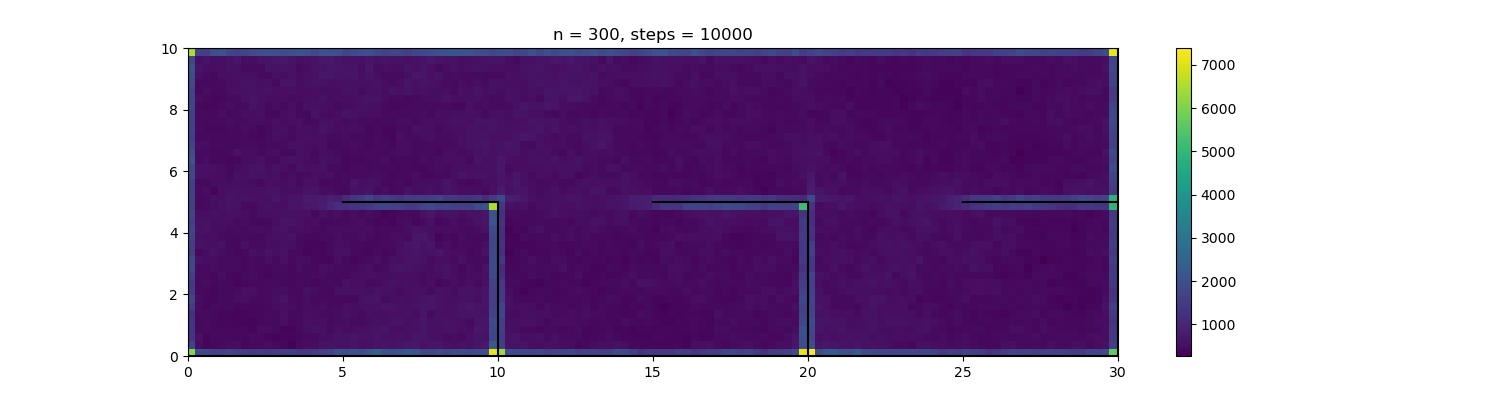

In [9]:
plt.figure(figsize=(15,4))
plt.title("n = 300, steps = 10000")
# plt.xlim(-0.3,30.3)
# plt.ylim(-0.1,10.1)
plt.hist2d(path.T[0],path.T[1],bins=[120,40], range=[[0, 30], [0, 10]])
plt.colorbar()
# plt.plot(path.T[0],path.T[1])
for w in c.get_walls():
    w.draw(plt.gca())
# plt.savefig('density_small_field.png', dpi=300)

In [41]:
import cProfile
cProfile.run('simulation(1,10000)')

         979722 function calls in 13.705 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.189    0.189   13.698   13.698 <ipython-input-5-f0dcf0df2ce5>:1(simulation)
        1    0.006    0.006   13.705   13.705 <string>:1(<module>)
    20066    0.154    0.000    2.748    0.000 iostream.py:195(schedule)
    20000    0.066    0.000    0.111    0.000 iostream.py:307(_is_master_process)
    20000    0.036    0.000    0.039    0.000 iostream.py:320(_schedule_flush)
    20000    0.227    0.000    3.137    0.000 iostream.py:382(write)
    20066    0.036    0.000    0.036    0.000 iostream.py:93(_event_pipe)
      542    0.002    0.000    0.004    0.000 random.py:437(expovariate)
    25430    1.131    0.000    1.131    0.000 runtumble.py:11(cross)
    28969    0.171    0.000    0.171    0.000 runtumble.py:14(dot)
      802    0.001    0.000    0.001    0.000 runtumble.py:209(get_walls)
    37700    0.020    0.000    